# Electric Vehicle Sales Analysis in India

## Objective
The objective of this project is to analyze electric vehicle (EV) sales trends across different states in India, identify key patterns, and forecast future EV adoption using machine learning techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [11]:
df = pd.read_csv("../data/ev_sales_india.csv")
df.head()

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014.0,jan,1/1/2014,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0
1,2014.0,jan,1/1/2014,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0
2,2014.0,jan,1/1/2014,Andhra Pradesh,AMBULANCE,Others,Others,0.0
3,2014.0,jan,1/1/2014,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0
4,2014.0,jan,1/1/2014,Andhra Pradesh,BUS,Bus,Bus,0.0


In [12]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               96845 non-null  float64
 1   Month_Name         96845 non-null  object 
 2   Date               96845 non-null  object 
 3   State              96845 non-null  object 
 4   Vehicle_Class      96845 non-null  object 
 5   Vehicle_Category   96845 non-null  object 
 6   Vehicle_Type       96845 non-null  object 
 7   EV_Sales_Quantity  96845 non-null  float64
dtypes: float64(2), object(6)
memory usage: 5.9+ MB


Year                 0
Month_Name           0
Date                 0
State                0
Vehicle_Class        0
Vehicle_Category     0
Vehicle_Type         0
EV_Sales_Quantity    0
dtype: int64

In [13]:
df.shape

(96845, 8)

In [14]:
df.columns

Index(['Year', 'Month_Name', 'Date', 'State', 'Vehicle_Class',
       'Vehicle_Category', 'Vehicle_Type', 'EV_Sales_Quantity'],
      dtype='object')

In [15]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")
df.columns

Index(['year', 'month_name', 'date', 'state', 'vehicle_class',
       'vehicle_category', 'vehicle_type', 'ev_sales_quantity'],
      dtype='object')

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df = df.drop_duplicates()

In [18]:
df = df.dropna()

In [20]:
df.dtypes

year                 float64
month_name            object
date                  object
state                 object
vehicle_class         object
vehicle_category      object
vehicle_type          object
ev_sales_quantity    float64
dtype: object

In [21]:
yearly_sales = (df.groupby("year")["ev_sales_quantity"].sum().reset_index())
yearly_sales

,year,ev_sales_quantity
0,2014.0,2392.0
1,2015.0,7805.0
2,2016.0,49855.0
3,2017.0,87420.0
4,2018.0,130254.0
5,2019.0,166819.0
6,2020.0,124684.0
7,2021.0,331498.0
8,2022.0,1024723.0
9,2023.0,1525179.0


## Exploratory Data Analysis (EDA)
In this section, exploratory data analysis is performed to understand trends in EV adoption over time, state-wise performance, and distribution across vehicle categories and types.

##LINE CHART

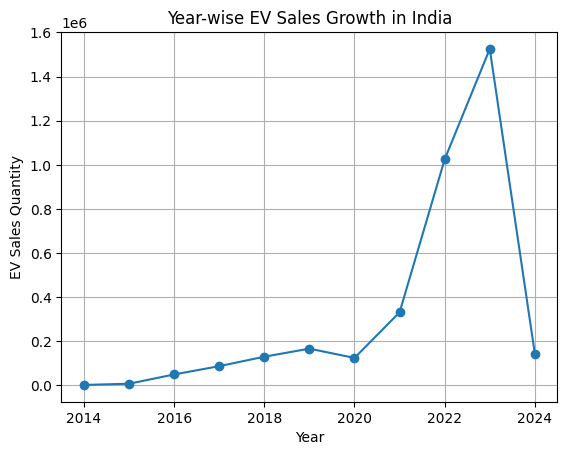

In [22]:
plt.figure()
plt.plot(
    yearly_sales["year"],
    yearly_sales["ev_sales_quantity"],
    marker="o"
)
plt.title("Year-wise EV Sales Growth in India")
plt.xlabel("Year")
plt.ylabel("EV Sales Quantity")
plt.grid(True)
plt.show()

In [23]:
state_sales = (
    df.groupby("state")["ev_sales_quantity"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

state_sales.head(10)

,state,ev_sales_quantity
0,Uttar Pradesh,732074.0
1,Maharashtra,401535.0
2,Karnataka,315498.0
3,Delhi,268538.0
4,Rajasthan,228573.0
5,Bihar,213465.0
6,Tamil Nadu,206902.0
7,Gujarat,176713.0
8,Assam,151917.0
9,Kerala,133246.0


BAR CHART - TOP 10 STATES


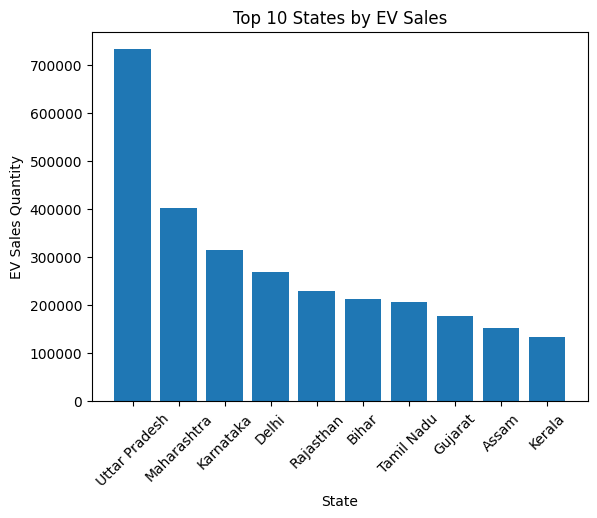

In [24]:
plt.figure()
plt.bar(
    state_sales["state"][:10],
    state_sales["ev_sales_quantity"][:10]
)
plt.xticks(rotation=45)
plt.title("Top 10 States by EV Sales")
plt.xlabel("State")
plt.ylabel("EV Sales Quantity")
plt.show()

In [26]:
category_sales = (
    df.groupby("vehicle_category")["ev_sales_quantity"]
    .sum()
    .reset_index()
)

category_sales

,vehicle_category,ev_sales_quantity
0,2-Wheelers,1808105.0
1,3-Wheelers,1620310.0
2,4-Wheelers,149775.0
3,Bus,7009.0
4,Others,8612.0


Pie Chart

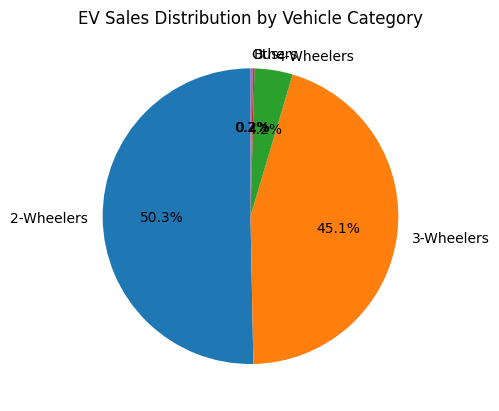

In [27]:
plt.figure()
plt.pie(
    category_sales["ev_sales_quantity"],
    labels=category_sales["vehicle_category"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("EV Sales Distribution by Vehicle Category")
plt.show()

In [28]:
vehicle_type_sales = (
    df.groupby("vehicle_type")["ev_sales_quantity"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

vehicle_type_sales.head(10)

,vehicle_type,ev_sales_quantity
0,2W_Personal,1796340.0
1,3W_Shared_LowSpeed,1408127.0
2,4W_Personal,130676.0
3,3W_Goods_LowSpeed,90656.0
4,3W_Shared,76132.0
5,3W_Goods,44974.0
6,4W_Shared,19099.0
7,2W_Shared,11765.0
8,Others,8612.0
9,Bus,7009.0


Bar chart

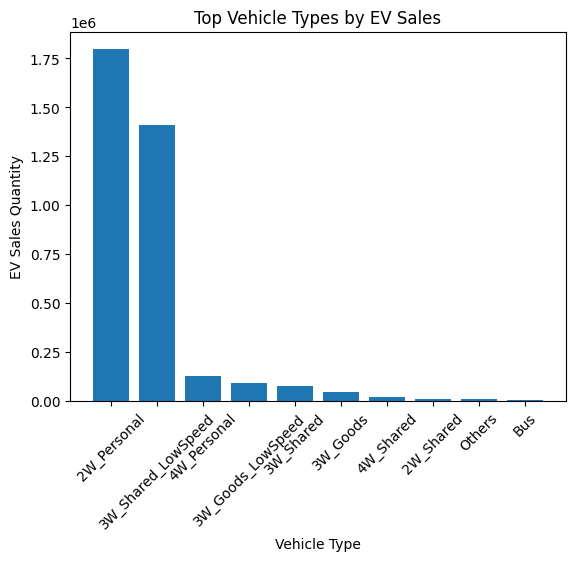

In [29]:
plt.figure()
plt.bar(
    vehicle_type_sales["vehicle_type"][:10],
    vehicle_type_sales["ev_sales_quantity"][:10]
)
plt.xticks(rotation=45)
plt.title("Top Vehicle Types by EV Sales")
plt.xlabel("Vehicle Type")
plt.ylabel("EV Sales Quantity")
plt.show()

In [30]:
df.to_csv("../data/ev_sales_cleaned.csv", index=False)

In [32]:
yearly_sales.to_csv("../data/yearly_sales_summary.csv", index=False)

In [33]:
state_sales.to_csv("../data/state_sales_summary.csv", index=False)

## Machine Learning – EV Sales Forecast
A Linear Regression model is used to predict future EV sales based on historical year-wise sales data.

MACHINE LEARNING 

In [35]:
from sklearn.linear_model import LinearRegression

X = yearly_sales[["year"]]
y = yearly_sales["ev_sales_quantity"]

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


PREDICTION FOR NEXT 5 YEARS

In [38]:
yearly_sales["year"] = yearly_sales["year"].astype(int)

In [39]:
last_year = yearly_sales["year"].max()

future_years = pd.DataFrame({
    "year": list(range(last_year + 1, last_year + 6))
})

In [40]:
future_years["predicted_ev_sales"] = model.predict(future_years)
future_years

,year,predicted_ev_sales
0,2025,8.820175e+05
1,2026,9.745687e+05
2,2027,1.067120e+06
3,2028,1.159671e+06
4,2029,1.252222e+06


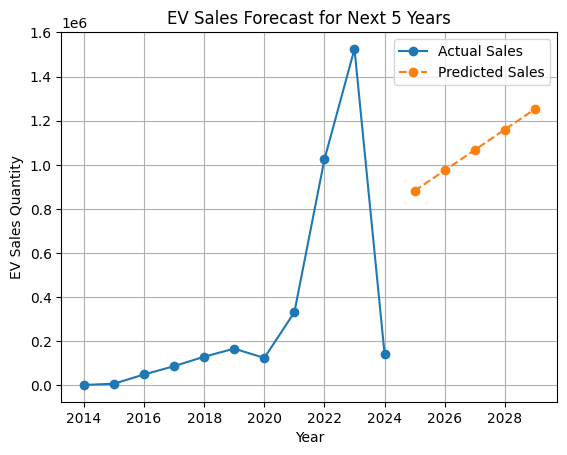

In [41]:
plt.figure()
plt.plot(
    yearly_sales["year"],
    yearly_sales["ev_sales_quantity"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    future_years["year"],
    future_years["predicted_ev_sales"],
    marker="o",
    linestyle="--",
    label="Predicted Sales"
)

plt.title("EV Sales Forecast for Next 5 Years")
plt.xlabel("Year")
plt.ylabel("EV Sales Quantity")
plt.legend()
plt.grid(True)
plt.show()